In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from pathlib import Path

# Configuration des chemins alignée avec la structure du projet
DATA_DIR = Path("../data/images")
TEMP_DIR = Path("../temp_download")

print("Environnement configuré pour l'exploration des données.")

Environnement configuré pour l'exploration des données.


In [2]:
# Exploration des données nettoyées et prêtes pour l'entraînement
if DATA_DIR.exists():
    all_files = os.listdir(DATA_DIR)
    
    # Comptage basé sur le renommage de ton script : "category_filename"
    dandelion_count = sum(1 for f in all_files if f.startswith("dandelion_"))
    grass_count = sum(1 for f in all_files if f.startswith("grass_"))
    
    # Création d'un DataFrame pour l'analyse
    df_stats = pd.DataFrame({
        'Classe': ['Dandelion', 'Grass'],
        'Nombre d\'images': [dandelion_count, grass_count]
    })
    
    print("--- Distribution du Dataset Nettoyé ---")
    print(df_stats.to_string(index=False))
else:
    print(f"Le dossier {DATA_DIR} n'existe pas encore. Lance d'abord le script de nettoyage.")

--- Distribution du Dataset Nettoyé ---
   Classe  Nombre d'images
Dandelion                0
    Grass                0


/tmp/ipykernel_38138/4121520924.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


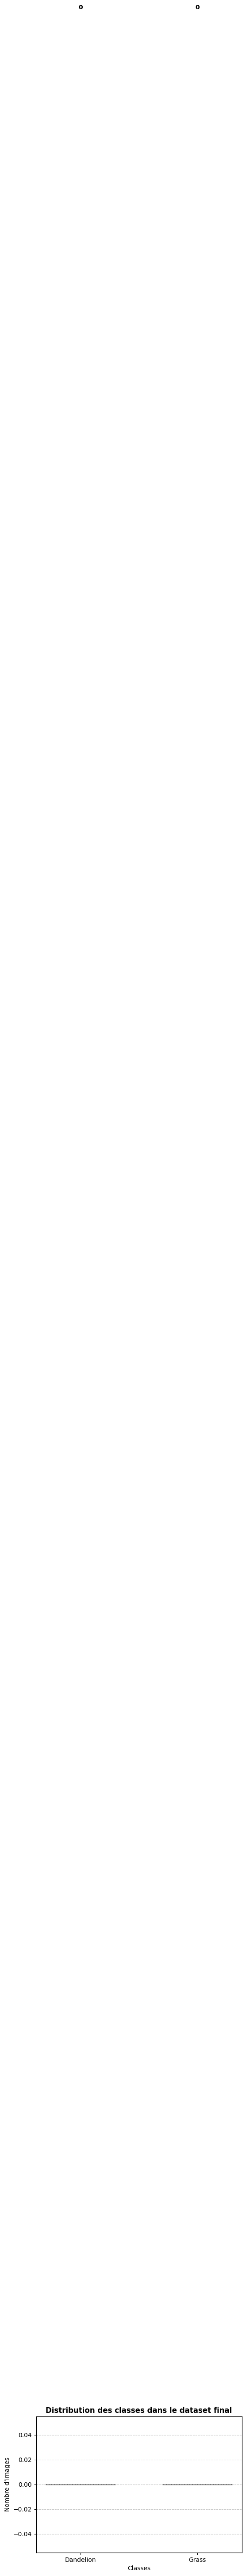

In [3]:
# Génération d'un graphique à barres pour le rapport de soutenance
plt.figure(figsize=(6, 4))
colors = ['#ffcc00', '#2ecc71'] # Jaune pour le pissenlit, Vert pour l'herbe
plt.bar(df_stats['Classe'], df_stats['Nombre d\'images'], color=colors, edgecolor='black', width=0.6)

plt.title("Distribution des classes dans le dataset final", fontsize=12, fontweight='bold')
plt.xlabel("Classes", fontsize=10)
plt.ylabel("Nombre d'images", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Affichage des valeurs sur les barres
for index, value in enumerate(df_stats['Nombre d\'images']):
    plt.text(index, value + 2, str(value), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [4]:
def plot_image_transformation(category, sample_filename):
    """Affiche l'image brute (temp_download) vs l'image nettoyée (data/images)"""
    raw_path = TEMP_DIR / category / sample_filename
    cleaned_filename = f"{category}_{sample_filename}"
    cleaned_path = DATA_DIR / cleaned_filename
    
    if raw_path.exists() and cleaned_path.exists():
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        
        # Image originale
        img_raw = Image.open(raw_path)
        axes[0].imshow(img_raw)
        axes[0].set_title(f"Image originale : {category}\nFormat: {img_raw.format} | Taille: {img_raw.size}")
        axes[0].axis('off')
        
        # Image nettoyée par run_import_clean.py
        img_cleaned = Image.open(cleaned_path)
        axes[1].imshow(img_cleaned)
        axes[1].set_title(f"Image nettoyée & standardisée\nFormat: JPEG | Taille: {img_cleaned.size}")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("Fichiers d'exemples introuvables pour la comparaison.")

# Récupération automatique du premier fichier de la catégorie dandelion pour l'exemple
if TEMP_DIR.exists() and (TEMP_DIR / "dandelion").exists():
    examples = os.listdir(TEMP_DIR / "dandelion")
    if examples:
        plot_image_transformation("dandelion", examples[0])